# 01 — Data Understanding con módulos MLE

Este notebook introduce el cambio desde un análisis aislado hacia un proyecto modular.

**Objetivos:**
- Cargar datos mediante `src.data.load_customer_data`.
- Validar automáticamente estructura y reglas de negocio.
- Explorar calidad, distribución y señales de churn.
- Separar notebook, lógica reutilizable y configuración.


## 1. Configuración del entorno

Ejecute este notebook desde la raíz del repositorio.

En Google Colab, primero clone el repositorio y ubíquese dentro de él:

```python
!git clone <URL_DEL_REPOSITORIO>
%cd customer-intelligence-ml-platform
```


In [20]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")


Project root: /workspaces/customer-intelligence-ml-plaform/entregable_D3_16_repositorio_final_curso_1


## 2. Importación de módulos del proyecto


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_customer_data, validate_customer_data
from src.utils import get_project_path, get_logger

logger = get_logger("notebook.data_understanding")


## 3. Carga y validación del dataset


In [22]:
DATA_PATH = get_project_path("data", "raw", "customer_churn.csv")

df = load_customer_data(
    DATA_PATH,
    validate=True,
    require_target=True,
    minimum_rows=100,
)

logger.info("Dataset loaded successfully with shape %s", df.shape)
df.head()


2026-09-02 01:29:26,201 | INFO | src.data.data_loader | Loaded customer dataset with shape (1000, 21)
2026-09-02 01:29:26,201 | INFO | notebook.data_understanding | Dataset loaded successfully with shape (1000, 21)


,customer_id,gender,age,region,customer_segment,contract_type,tenure_months,monthly_fee,total_spent,internet_service,...,streaming_service,support_calls,complaints,payment_method,last_payment_delay,digital_usage_score,marketing_score,preferred_contact_hour,internal_campaign_code,churn
0,NT-000001,Masculino,28.0,Lima,Masivo,Anual,40,114.04,3812.50,Fibra,...,No,0,1,Transferencia,2,90.4,69.5,20,CMP-D,0
1,NT-000002,Femenino,50.0,Norte,Masivo,Anual,12,115.97,1468.32,Fibra,...,Sí,1,1,Transferencia,1,63.7,64.2,17,CMP-D,0
2,NT-000003,Masculino,38.0,Lima,Joven digital,Mensual,32,114.42,3128.82,Fibra,...,No,2,0,Tarjeta,5,94.5,63.1,10,CMP-D,1
3,NT-000004,Masculino,34.0,Norte,Joven digital,Anual,54,41.89,2037.76,Sin internet,...,No,1,1,Tarjeta,5,33.3,53.0,12,CMP-C,0
4,NT-000005,Femenino,37.0,Lima,Joven digital,Bianual,9,91.54,790.10,Fibra,...,No,2,1,Tarjeta,2,73.8,85.7,12,CMP-B,0


In [23]:
report = validate_customer_data(df)
report.to_dict()


{'rows': 1000,
 'columns': 21,
 'duplicate_customer_ids': 0,
 'missing_values': 256,
 'churn_rate': 0.24}

## 4. Inspección general

En esta sección se revisan dimensiones, tipos de datos y primeras observaciones.


In [24]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())


Rows: 1,000
Columns: 21


,customer_id,gender,age,region,customer_segment,contract_type,tenure_months,monthly_fee,total_spent,internet_service,...,streaming_service,support_calls,complaints,payment_method,last_payment_delay,digital_usage_score,marketing_score,preferred_contact_hour,internal_campaign_code,churn
0,NT-000001,Masculino,28.0,Lima,Masivo,Anual,40,114.04,3812.50,Fibra,...,No,0,1,Transferencia,2,90.4,69.5,20,CMP-D,0
1,NT-000002,Femenino,50.0,Norte,Masivo,Anual,12,115.97,1468.32,Fibra,...,Sí,1,1,Transferencia,1,63.7,64.2,17,CMP-D,0
2,NT-000003,Masculino,38.0,Lima,Joven digital,Mensual,32,114.42,3128.82,Fibra,...,No,2,0,Tarjeta,5,94.5,63.1,10,CMP-D,1
3,NT-000004,Masculino,34.0,Norte,Joven digital,Anual,54,41.89,2037.76,Sin internet,...,No,1,1,Tarjeta,5,33.3,53.0,12,CMP-C,0
4,NT-000005,Femenino,37.0,Lima,Joven digital,Bianual,9,91.54,790.10,Fibra,...,No,2,1,Tarjeta,2,73.8,85.7,12,CMP-B,0


In [25]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             1000 non-null   object 
 1   gender                  1000 non-null   object 
 2   age                     959 non-null    float64
 3   region                  951 non-null    object 
 4   customer_segment        1000 non-null   object 
 5   contract_type           1000 non-null   object 
 6   tenure_months           1000 non-null   int64  
 7   monthly_fee             1000 non-null   float64
 8   total_spent             957 non-null    float64
 9   internet_service        967 non-null    object 
 10  tv_service              1000 non-null   object 
 11  streaming_service       1000 non-null   object 
 12  support_calls           1000 non-null   int64  
 13  complaints              1000 non-null   int64  
 14  payment_method          1000 non-null   o

In [26]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1000,1000,NT-000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,1000,2,Masculino,507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,959.0,NaN,NaN,NaN,37.324296,12.359277,18.0,28.0,37.0,46.0,76.0
region,951,5,Lima,419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,1000,4,Masivo,429,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contract_type,1000,3,Mensual,512,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,1000.0,NaN,NaN,NaN,36.794,23.453947,1.0,19.0,32.0,48.0,120.0
monthly_fee,1000.0,NaN,NaN,NaN,102.97312,42.083567,35.0,84.2525,102.815,118.4675,555.39
total_spent,957.0,NaN,NaN,NaN,3388.851003,2385.190682,42.07,1598.7,2837.85,4609.73,18098.14
internet_service,967,3,Fibra,531,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Calidad de datos


In [27]:
missing_summary = (
    df.isna()
      .sum()
      .to_frame("missing_count")
      .assign(missing_pct=lambda x: x["missing_count"] / len(df) * 100)
      .query("missing_count > 0")
      .sort_values("missing_pct", ascending=False)
)

missing_summary


,missing_count,missing_pct
region,49,4.9
marketing_score,45,4.5
digital_usage_score,45,4.5
total_spent,43,4.3
age,41,4.1
internet_service,33,3.3


In [28]:
duplicate_ids = df["customer_id"].duplicated().sum()
duplicate_rows = df.duplicated().sum()

print(f"Duplicated customer IDs: {duplicate_ids}")
print(f"Duplicated complete rows: {duplicate_rows}")


Duplicated customer IDs: 0
Duplicated complete rows: 0


## 6. Distribución de la variable objetivo


In [29]:
target_summary = (
    df["churn"]
    .value_counts(dropna=False)
    .rename_axis("churn")
    .to_frame("count")
)

target_summary["percentage"] = target_summary["count"] / len(df) * 100
target_summary


,count,percentage
churn,,
0,760,76.0
1,240,24.0


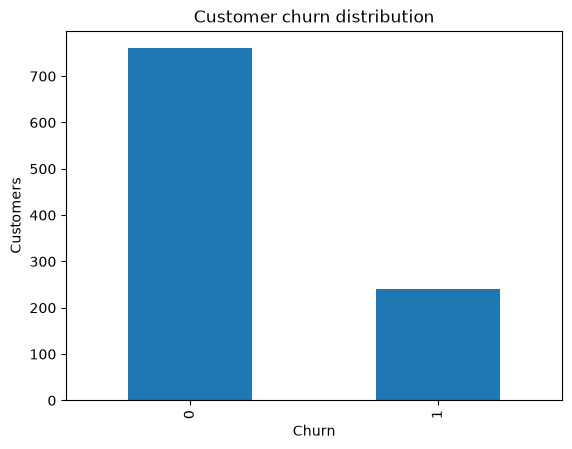

In [30]:
ax = df["churn"].value_counts().sort_index().plot(kind="bar")
ax.set_title("Customer churn distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Customers")
plt.show()


## 7. Análisis numérico


In [31]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
numeric_columns


['age',
 'tenure_months',
 'monthly_fee',
 'total_spent',
 'support_calls',
 'complaints',
 'last_payment_delay',
 'digital_usage_score',
 'marketing_score',
 'preferred_contact_hour',
 'churn']

In [32]:
correlations = (
    df[numeric_columns]
    .corr(numeric_only=True)["churn"]
    .drop("churn")
    .sort_values(key=abs, ascending=False)
)

correlations.to_frame("correlation_with_churn")


,correlation_with_churn
complaints,0.189890
tenure_months,-0.175749
total_spent,-0.161834
support_calls,0.075273
digital_usage_score,-0.060986
marketing_score,-0.048613
monthly_fee,-0.029632
last_payment_delay,0.020117
age,0.020059
preferred_contact_hour,0.006789


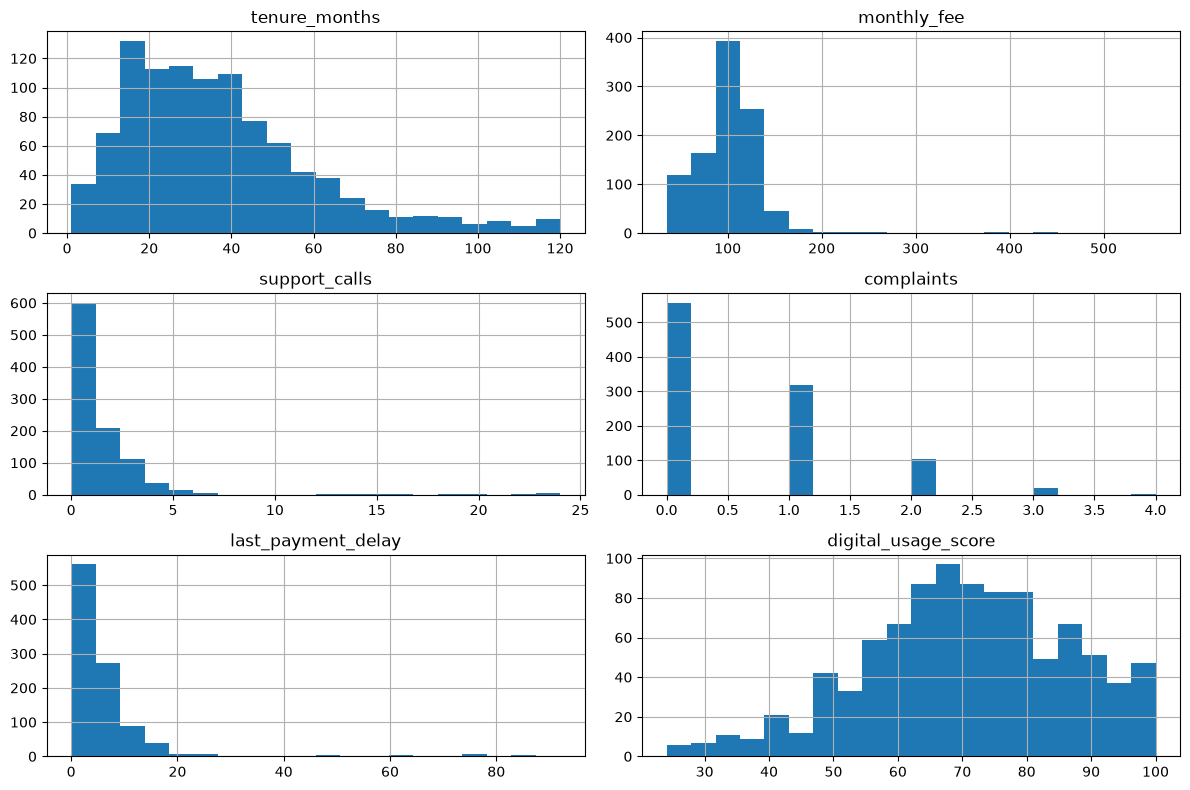

In [33]:
selected_numeric = [
    "tenure_months",
    "monthly_fee",
    "support_calls",
    "complaints",
    "last_payment_delay",
    "digital_usage_score",
]

df[selected_numeric].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()


## 8. Análisis categórico


In [34]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()
categorical_columns


['customer_id',
 'gender',
 'region',
 'customer_segment',
 'contract_type',
 'internet_service',
 'tv_service',
 'streaming_service',
 'payment_method',
 'internal_campaign_code']

In [35]:
def churn_rate_by_category(dataframe: pd.DataFrame, column: str) -> pd.DataFrame:
    return (
        dataframe.groupby(column, dropna=False)["churn"]
        .agg(customer_count="size", churn_rate="mean")
        .sort_values("churn_rate", ascending=False)
    )

churn_rate_by_category(df, "contract_type")


,customer_count,churn_rate
contract_type,,
Mensual,512,0.330078
Anual,332,0.168675
Bianual,156,0.096154


In [36]:
churn_rate_by_category(df, "internet_service")


,customer_count,churn_rate
internet_service,,
DSL,324,0.333333
NaN,33,0.272727
Fibra,531,0.197740
Sin internet,112,0.160714


In [37]:
churn_rate_by_category(df, "payment_method")


,customer_count,churn_rate
payment_method,,
Débito automático,326,0.260736
Efectivo,111,0.252252
Transferencia,277,0.245487
Tarjeta,286,0.206294


## 9. Hallazgos preliminares

Complete esta sección con conclusiones sustentadas en resultados:

1. ¿Qué variables presentan valores faltantes?
2. ¿Existe desbalance en `churn`?
3. ¿Qué variables numéricas tienen mayor relación con el target?
4. ¿Qué categorías muestran mayor tasa de churn?
5. ¿Qué variables deben excluirse antes del modelado?


In [38]:
student_findings = {
    "missing_values": "",
    "class_balance": "",
    "numeric_signals": "",
    "categorical_signals": "",
    "variables_to_exclude": "",
}

student_findings


{'missing_values': '',
 'class_balance': '',
 'numeric_signals': '',
 'categorical_signals': '',
 'variables_to_exclude': ''}

## 10. Checklist de salida

Antes de cerrar el notebook, verifique:

- [ ] El dataset fue cargado usando `load_customer_data`.
- [ ] La validación terminó sin errores.
- [ ] Se revisaron valores faltantes y duplicados.
- [ ] Se analizó la distribución del target.
- [ ] Se identificaron variables candidatas para el modelo.
- [ ] Se documentaron decisiones preliminares de limpieza.


## Resultado esperado

Este notebook ya no contiene lógica crítica de carga o validación.  
La lógica reusable reside en `src/`, mientras que el notebook conserva la exploración, interpretación y comunicación de resultados.
